<a href="https://colab.research.google.com/github/MohHaroon/XAI-based-ZSL-for-IIDS/blob/master/ZSAL_and_SOAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Implementation of the Zero-shot Attribution Layer and SHAP Overlap Automation Model (SOAM)

### Load CatBoost model and data splits

In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.3 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Reloading CatBoost
from catboost import CatBoostClassifier
loaded_cat = CatBoostClassifier()
loaded_cat.load_model('/content/drive/MyDrive/IRP_Models/catboost_sdn_20260123_040438.cbm')

In [14]:
import os
import joblib
import pandas as pd

base_path = '/content/drive/MyDrive/IRP_Models/'
split_path = os.path.join(base_path, 'Data_Splits/')

X_train = joblib.load(os.path.join(split_path, f'X_train.pkl'))
X_test = joblib.load(os.path.join(split_path, f'X_test.pkl'))
y_train = joblib.load(os.path.join(split_path, f'y_train.pkl'))
y_test = joblib.load(os.path.join(split_path, f'y_test.pkl'))


# Adding the column names
feature_names = ["proto_number", "Dur", "Mean", "Stddev", "Min", "Max", "Pkts", "Bytes",
                 "Spkts", "Dpkts", "Sbytes", "Dbytes", "Srate", "Drate", "Sum",
                 "TnBPSrcIP", "TnBPDstIP", "TnP_PSrcIP", "TnP_PDstIP", "TnP_PerProto",
                 "TnP_Per_Dport", "N_IN_Conn_P_DstIP", "N_IN_Conn_P_SrcIP"]

X_test = pd.DataFrame(X_test, columns=feature_names)
X_train = pd.DataFrame(X_train, columns=feature_names)

print(f"\nSuccessfully loaded Data Splits for {len(X_test)} test packets.")


Successfully loaded Data Splits for 42000 test packets.


In [17]:
print(len(X_test[0]))

23


In [18]:
import pandas as pd
SDN_train_test_data = pd.read_csv("/content/drive/MyDrive/IRP/SDN-Dataset/SDN_data.csv")

In [20]:
print(SDN_train_test_data.head(0))

Empty DataFrame
Columns: [proto_number, Dur, Mean, Stddev, Min, Max, Pkts, Bytes, Spkts, Dpkts, Sbytes, Dbytes, Srate, Drate, Sum, TnBPSrcIP, TnBPDstIP, TnP_PSrcIP, TnP_PDstIP, TnP_PerProto, TnP_Per_Dport, N_IN_Conn_P_DstIP, N_IN_Conn_P_SrcIP, Attack]
Index: []

[0 rows x 24 columns]


Monitoring SDN Traffic...
ALARM: Anomaly detected at packet index 0


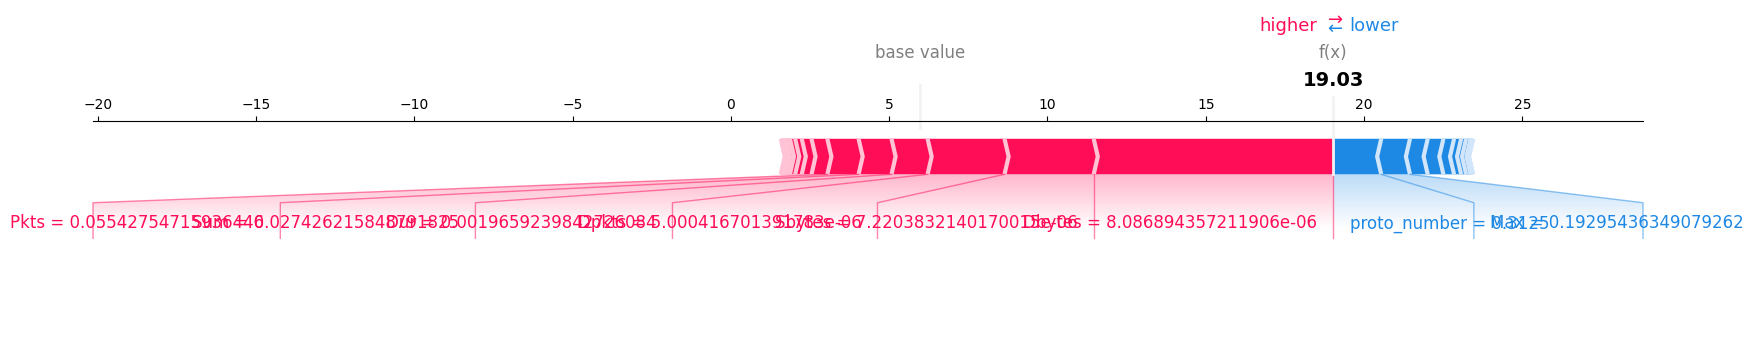

In [10]:
import shap

# 1. Initialize Explainer (Component 3)
explainer = shap.TreeExplainer(loaded_cat)

# 2. Simulate SDIN Monitoring
print("Monitoring SDN Traffic...")
found_anomaly = False

for i in range(len(X_test)):
    # Get a single packet instance
    instance = X_test.iloc[i:i+1]

    # Inference
    prediction = loaded_cat.predict(instance)[0]

    if prediction == 1:  # Anomaly Detected!
        print(f"ALARM: Anomaly detected at packet index {i}")

        # 3. Generate SHAP values for this specific instance
        instance_shap = explainer.shap_values(instance)

        # 4. Generate the Visualization for Feature Provenance
        shap.force_plot(explainer.expected_value, instance_shap[0], instance, matplotlib=True)

        # Capture for ZASL Labeling
        target_instance = instance
        target_shap = instance_shap[0]
        found_anomaly = True
        break

if not found_anomaly:
    print("No anomalies detected in the current traffic batch.")

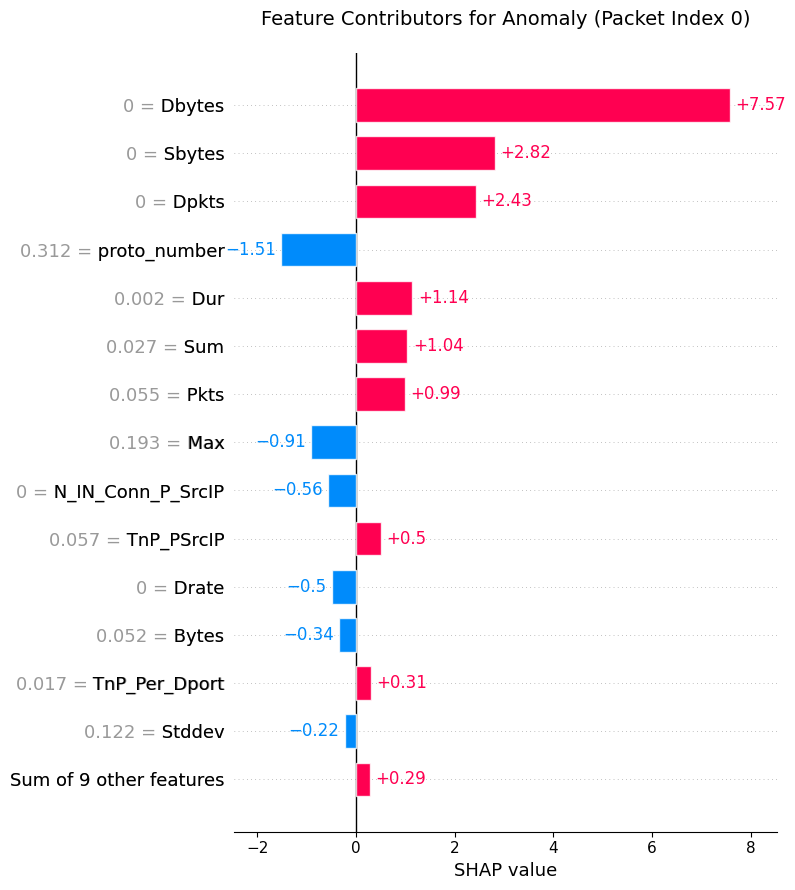

In [22]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

# --- Assuming you are running this right after the anomaly detection loop ---
# You need these variables from your previous step:
# 1. target_shap (The numpy array of SHAP values for the anomaly)
# 2. instance_df (The Pandas DataFrame of the single anomaly row)
# 3. explainer.expected_value (The base value of the model)

# 1. Wrap data into a SHAP Explanation object for plotting
# We take the first (and only) row of the instance_df and target_shap
shap_explanation = shap.Explanation(
    values=target_shap,               # The SHAP values for this instance
    base_values=explainer.expected_value, # The average model output
    data=instance.iloc[0],         # The actual feature values for this row
    feature_names=instance.columns # The feature names
)

# 2. Create the Vertical Bar Plot
plt.figure(figsize=(12, 8)) # Increase size for better readability

# max_display=15 ensures only the top 15 most influential features are shown
shap.plots.bar(shap_explanation, max_display=15, show=False)

plt.title(f"Feature Contributors for Anomaly (Packet Index {i})", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

In [23]:
def generate_zasl_label(shap_values, feature_names):
    # Find indices of features that have a POSITIVE impact (pushing towards Attack)
    # We sort them to find the strongest drivers shown in your red SHAP bars
    positive_contributions = [(val, name) for val, name in zip(shap_values, feature_names) if val > 0]

    # Sort by impact (highest value first)
    sorted_contributions = sorted(positive_contributions, key=lambda x: x[0], reverse=True)

    # Extract top 2 or 3 most influential features
    top_features = [item[1] for item in sorted_contributions[:3]]

    if not top_features:
        return "Generic Anomaly"

    return f"{'-'.join(top_features)}-based-Attribution"

# Usage with your specific instance
# feature_names = X_test.columns.tolist()
zasl_name = generate_zasl_label(target_shap, feature_names)
print(f"ZASL Final Label: {zasl_name}")

ZASL Final Label: Dbytes-Sbytes-Dpkts-based-Attribution
